### generic scenario plots

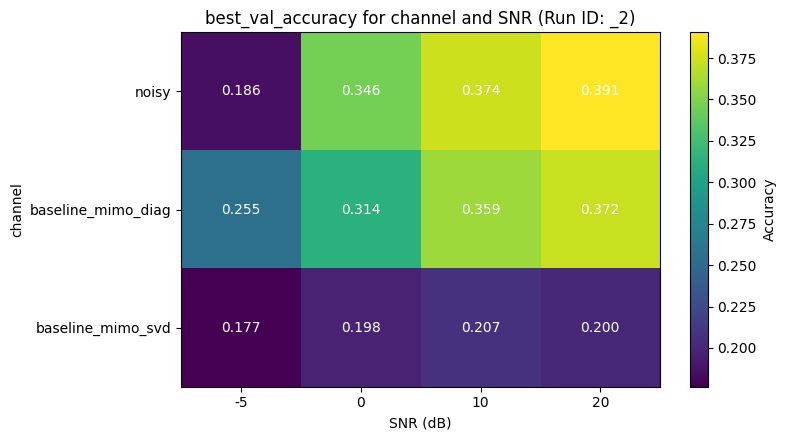

Accuracy clean (best_val_accuracy): 0.375000


In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# Specifica l'ID della run da caricare (es. "", "_1", "_2", etc.)
# Se lasci "", cercherà le cartelle base (es. comm=noisy)
run_id = "_2" 
# ---------------------

# Trova la cartella risultati sia se il notebook e lanciato da root sia da Documents
candidate_roots = [
    Path("results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
    Path("../results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
]

root = None
for cand in candidate_roots:
    if cand.exists():
        root = cand
        break

if root is None:
    raise FileNotFoundError("Radice dei risultati non trovata nelle locazioni candidate.")

accuracy_by_channel = {}
clean_acc = None

# Canali previsti nell'ordine di visualizzazione
desired_order = ["noisy", "baseline_mimo_diag", "baseline_mimo_svd"]

# 1. Gestione speciale per CLEAN (Fallback su 'clean' se 'clean{run_id}' non esiste)
clean_folder_name = f"comm=clean{run_id}"
clean_path = root / clean_folder_name
if not clean_path.exists():
    # Fallback su cartella clean base
    clean_path = root / "comm=clean"

if clean_path.exists():
    json_path = clean_path / "best_training_results.json"
    if json_path.exists():
        data = json.loads(json_path.read_text(encoding="utf-8"))
        best_val = data.get("best_val_accuracy")
        clean_acc = float(best_val) if best_val is not None else None
    else:
        print(f"Warning: File non trovato in {clean_path}")

# 2. Caricamento altri canali (Errore se non presenti)
for base_name in desired_order:
    folder_name = f"comm={base_name}{run_id}"
    channel_path = root / folder_name
    
    if not channel_path.exists():
        raise FileNotFoundError(f"Errore: la cartella richiesta '{folder_name}' non è stata trovata in {root}")
    
    json_path = channel_path / "best_training_results.json"
    if not json_path.exists():
        raise FileNotFoundError(f"Errore: file 'best_training_results.json' mancante in {channel_path}")

    data = json.loads(json_path.read_text(encoding="utf-8"))
    best_val_accuracy = data.get("best_val_accuracy")

    if best_val_accuracy is not None:
        # Filtro SNR=5.0 come nel codice originale
        filtered = {
            float(k): float(v)
            for k, v in best_val_accuracy.items()
            if float(k) != 5.0
        }
        accuracy_by_channel[base_name] = filtered

# Costruisci matrice heatmap
channels_present = [c for c in desired_order if c in accuracy_by_channel]
snrs = sorted({snr for ch in channels_present for snr in accuracy_by_channel[ch].keys()})
matrix = [[accuracy_by_channel[ch].get(snr, float("nan")) for snr in snrs] for ch in channels_present]

# Plotting
fig, ax = plt.subplots(figsize=(8, 3 + 0.5 * len(channels_present)))
im = ax.imshow(matrix, aspect="auto")
fig.colorbar(im, ax=ax, label="Accuracy")

ax.set_xticks(range(len(snrs)))
ax.set_xticklabels([f"{s:g}" for s in snrs])
ax.set_yticks(range(len(channels_present)))
ax.set_yticklabels(channels_present)
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("channel")
ax.set_title(f"best_val_accuracy for channel and SNR (Run ID: {run_id if run_id else 'default'})")

for i in range(len(channels_present)):
    for j in range(len(snrs)):
        v = matrix[i][j]
        if v == v: # Check for NaN
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", color="white")

plt.tight_layout()
plt.show()

if clean_acc is not None:
    print(f"Accuracy clean (best_val_accuracy): {clean_acc:.6f}")


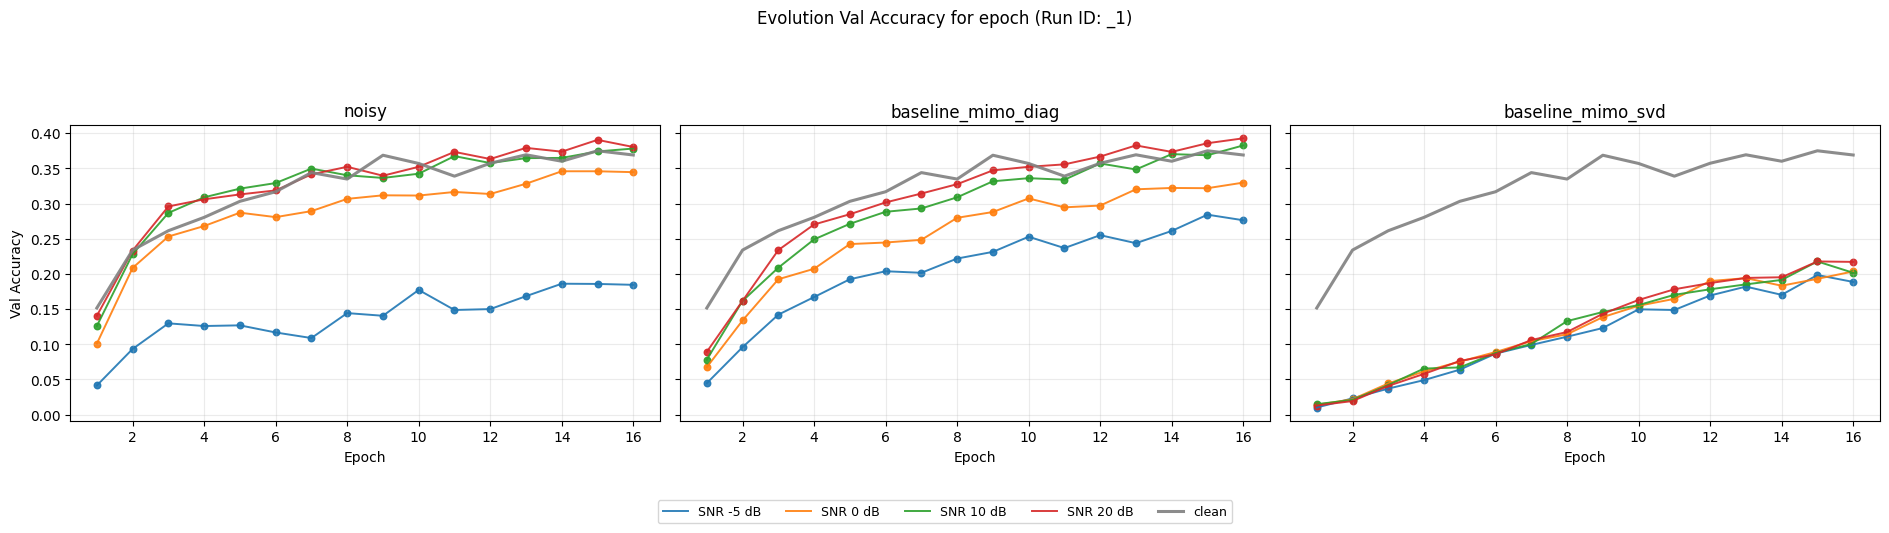

In [2]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# Specifica l'ID della run da caricare (es. "", "_1", "_2", etc.)
run_id = "_1" 
# ---------------------

# Trova la cartella proposal in modo robusto
candidate_proposal_roots = [
    Path("results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
    Path("../results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
]

proposal_root = None
for cand in candidate_proposal_roots:
    if cand.exists():
        proposal_root = cand
        break

if proposal_root is None:
    raise FileNotFoundError("Radice dei risultati 'proposal' non trovata.")

channels = ["noisy", "baseline_mimo_diag", "baseline_mimo_svd"]
channel_to_val_acc = {}

# 1. Caricamento canali (Errore se la cartella specifica run_id non esiste)
for channel in channels:
    folder_name = f"comm={channel}{run_id}"
    channel_path = proposal_root / folder_name
    
    if not channel_path.exists():
        raise FileNotFoundError(f"Errore: la cartella richiesta '{folder_name}' non è stata trovata in {proposal_root}")
        
    fp = channel_path / "final_training_results.json"
    if not fp.exists():
        raise FileNotFoundError(f"Errore: file 'final_training_results.json' mancante in {channel_path}")

    data = json.loads(fp.read_text(encoding="utf-8"))
    val_acc = data.get("Val accuracies")
    channel_to_val_acc[channel] = val_acc

# 2. Caricamento CLEAN (Fallback su 'clean' se 'clean{run_id}' manca)
clean_folder_name = f"comm=clean{run_id}"
clean_path = proposal_root / clean_folder_name
if not clean_path.exists():
    clean_path = proposal_root / "comm=clean"

if not clean_path.exists():
    raise FileNotFoundError(f"Errore: neanche la cartella clean base è stata trovata in {proposal_root}")

clean_fp = clean_path / "final_training_results.json"
if not clean_fp.exists():
    raise FileNotFoundError(f"Errore: file 'final_training_results.json' non trovato in {clean_path}")

clean_data = json.loads(clean_fp.read_text(encoding="utf-8"))
clean_val_acc = clean_data.get("Val accuracies")
clean_series = [float(v) for v in clean_val_acc]

# --- PLOTTING ---
fig, axes = plt.subplots(1, 3, figsize=(19, 5), sharey=True)

for ax, channel in zip(axes, channels):
    val_acc = channel_to_val_acc[channel]
    epochs = list(range(1, len(val_acc) + 1))

    # Estrai livelli SNR dai dati caricati
    snr_levels = sorted({float(snr) for epoch_dict in val_acc for snr in epoch_dict.keys()})

    for snr in snr_levels:
        key = str(int(snr)) if snr.is_integer() else str(snr)
        y = [float(epoch_dict.get(key, float("nan"))) for epoch_dict in val_acc]

        ax.scatter(epochs, y, s=22, alpha=0.9)
        ax.plot(epochs, y, linewidth=1.4, alpha=0.9, label=f"SNR {snr:g} dB")

    # Aggiunta serie clean
    n = min(len(epochs), len(clean_series))
    ax.plot(
        epochs[:n],
        clean_series[:n],
        color="gray",
        linewidth=2.2,
        linestyle="-",
        alpha=0.9,
        label="clean",
    )

    ax.set_title(f"{channel}")
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.25)

# Legenda unica condivisa
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02))

axes[0].set_ylabel("Val Accuracy")
fig.suptitle(f"Evolution Val Accuracy for epoch (Run ID: {run_id if run_id else 'default'})", y=1.02)
plt.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.show()


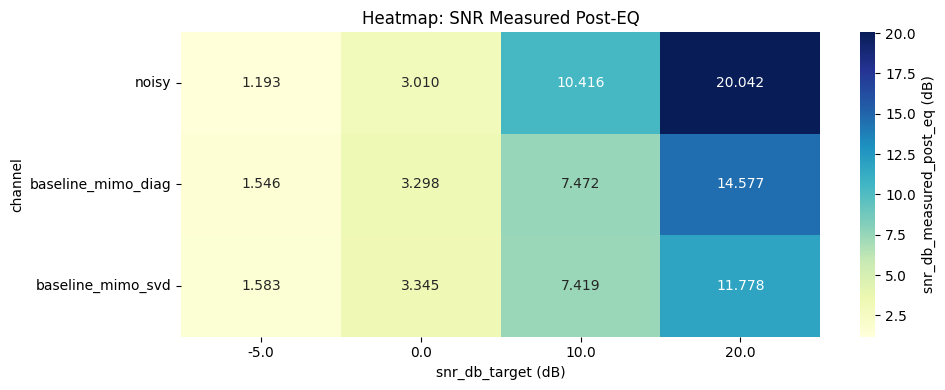

In [3]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- CONFIGURATION ---
# Specifica l'ID della run da caricare (es. "", "_1", "_2", etc.)
run_id = "_1" 
# ---------------------

# Trova la cartella proposal in modo robusto
candidate_proposal_roots = [
    Path("results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
    Path("../results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
]

proposal_root = None
for cand in candidate_proposal_roots:
    if cand.exists():
        proposal_root = cand
        break

if proposal_root is None:
    raise FileNotFoundError("Radice dei risultati 'proposal' non trovata.")

channels = ["noisy", "baseline_mimo_diag", "baseline_mimo_svd"]
rows = []
pattern = re.compile(r"^best_val_snr_db_measured_post_eq_snr_(.+)$")

# Caricamento canali (Errore se la cartella specifica run_id non esiste)
for channel in channels:
    folder_name = f"comm={channel}{run_id}"
    channel_path = proposal_root / folder_name
    
    if not channel_path.exists():
        raise FileNotFoundError(f"Errore: la cartella richiesta '{folder_name}' non è stata trovata in {proposal_root}")
        
    fp = channel_path / "best_training_results.json"
    if not fp.exists():
        raise FileNotFoundError(f"Errore: file 'best_training_results.json' mancante in {channel_path}")

    data = json.loads(fp.read_text(encoding="utf-8"))

    # Estrazione dati tramite regex
    for key, measured_post_eq in data.items():
        match = pattern.match(key)
        if not match:
            continue

        snr_suffix = match.group(1)
        target_key = f"best_val_snr_db_target_snr_{snr_suffix}"
        snr_target = data.get(target_key)

        if snr_target is None:
            continue

        rows.append(
            {
                "channel": channel,
                "snr_db_target": float(snr_target),
                "snr_db_measured_post_eq": float(measured_post_eq),
            }
        )

# Elaborazione DataFrame
plot_df = pd.DataFrame(rows)

if plot_df.empty:
    print(f"Nessun dato trovato per run_id: {run_id}")
else:
    plot_df = plot_df[plot_df["snr_db_target"] != 5.0]
    plot_df = plot_df.sort_values(["channel", "snr_db_target"]).reset_index(drop=True)

    # Heatmap: assi = canale e snr target, celle = snr measured post-eq
    pivot = plot_df.pivot(index="channel", columns="snr_db_target", values="snr_db_measured_post_eq")
    pivot = pivot.reindex(channels)
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)

    # Visualizzazione
    plt.figure(figsize=(10, 4))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        cbar_kws={"label": "snr_db_measured_post_eq (dB)"},
    )

    plt.title(f"Heatmap: SNR Measured Post-EQ")
    plt.xlabel("snr_db_target (dB)")
    plt.ylabel("channel")
    plt.tight_layout()
    plt.show()


### svd experiment

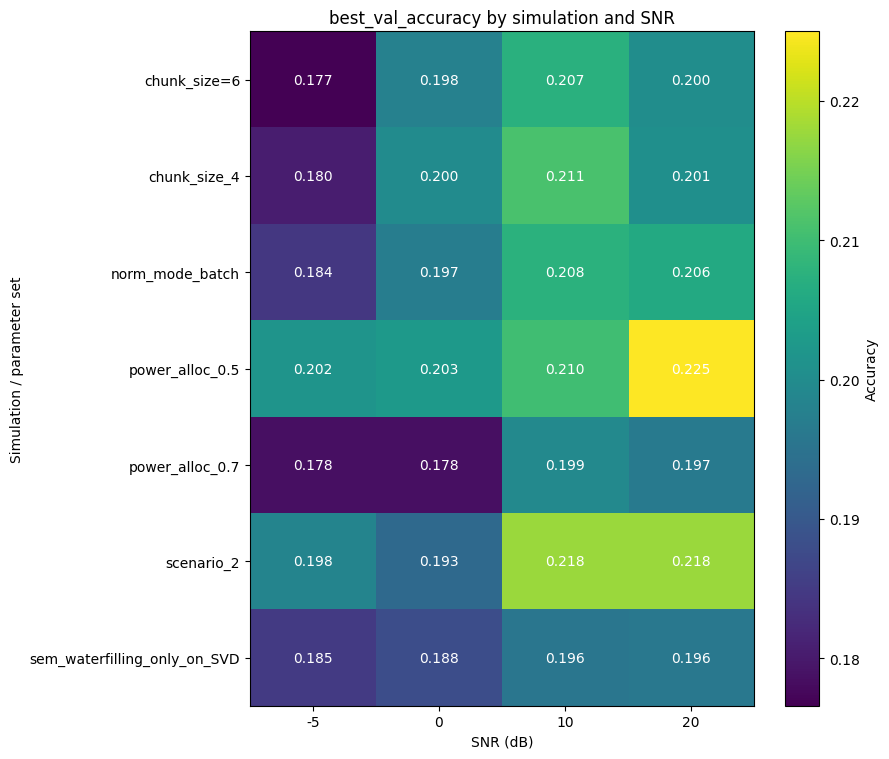

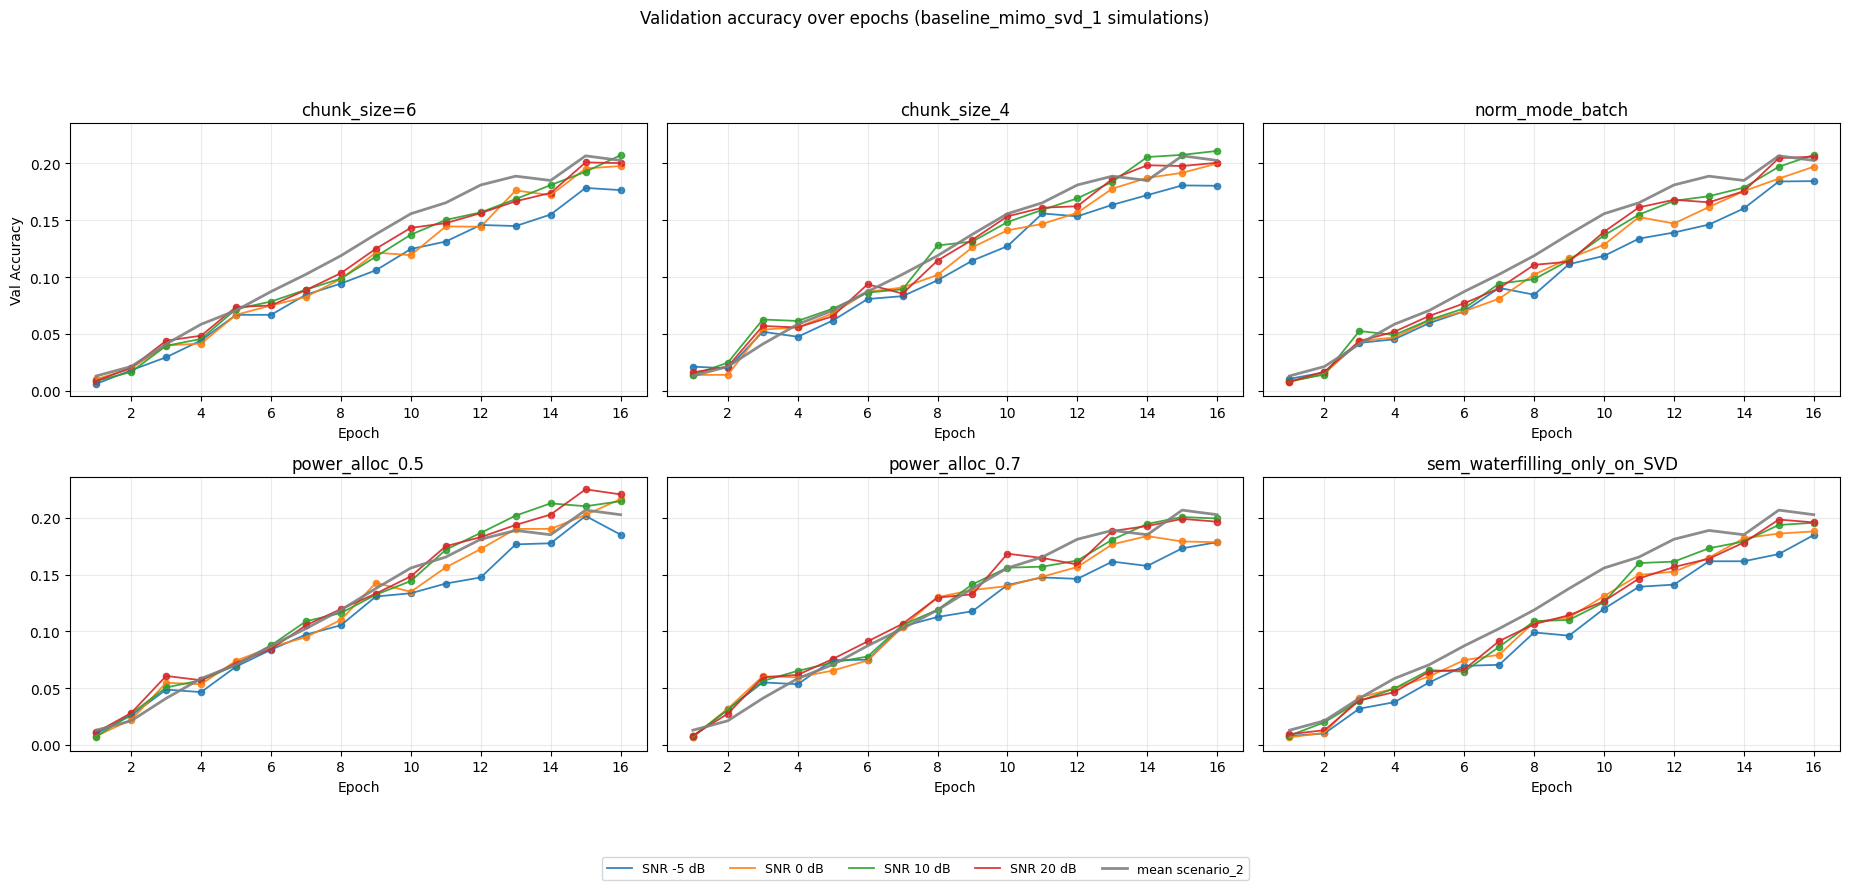

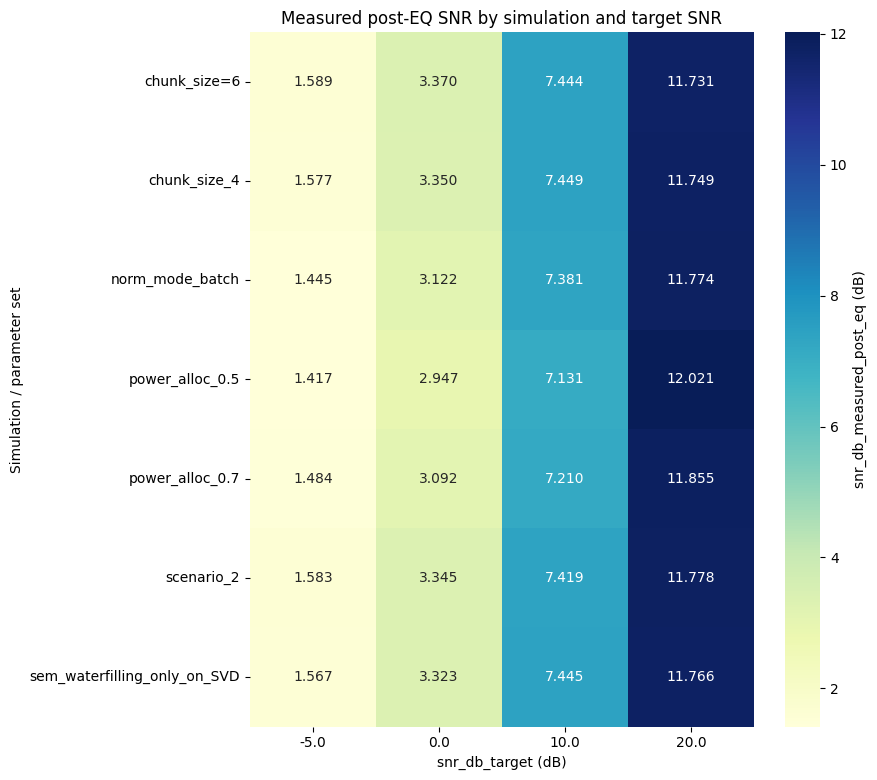

In [1]:
import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- CONFIGURATION ---
# You can exclude specific SNR values from plotting.
snr_to_exclude = {5.0}
scenario2_name = "scenario_2"

# Root folder for variable-parameter simulation runs
candidate_variant_roots = [
    Path("/results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal/comm=baseline_mimo_svd_exp"),
    Path("../results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal/comm=baseline_mimo_svd_exp"),
]

variant_root = None
for cand in candidate_variant_roots:
    if cand.exists():
        variant_root = cand
        break

if variant_root is None:
    raise FileNotFoundError("Root folder 'comm=baseline_mimo_svd_exp' not found in candidate locations.")

# Scan simulations: include each subfolder that contains both required JSON files
simulation_dirs = []
skipped_dirs = []
for child in sorted(variant_root.iterdir()):
    if not child.is_dir():
        continue
    best_fp = child / "best_training_results.json"
    final_fp = child / "final_training_results.json"
    if best_fp.exists() and final_fp.exists():
        simulation_dirs.append(child)
    else:
        skipped_dirs.append(child.name)

if not simulation_dirs:
    raise FileNotFoundError(
        f"No valid simulation found in {variant_root}. "
        "Expected both 'best_training_results.json' and 'final_training_results.json' in at least one subfolder."
    )

if skipped_dirs:
    print("Skipped folders (missing JSON files):", ", ".join(skipped_dirs))

sim_labels = [d.name for d in simulation_dirs]

# =====================================================================
# PLOT 1: best_val_accuracy heatmap (rows=simulations, columns=SNR)
# =====================================================================
best_acc_by_sim = {}
for sim_dir in simulation_dirs:
    data = json.loads((sim_dir / "best_training_results.json").read_text(encoding="utf-8"))
    best_val_accuracy = data.get("best_val_accuracy")
    if isinstance(best_val_accuracy, dict):
        filtered = {
            float(k): float(v)
            for k, v in best_val_accuracy.items()
            if float(k) not in snr_to_exclude
        }
        if filtered:
            best_acc_by_sim[sim_dir.name] = filtered

if not best_acc_by_sim:
    print("[Plot 1] No valid 'best_val_accuracy' values found.")
else:
    sim_present = [s for s in sim_labels if s in best_acc_by_sim]
    snrs = sorted({snr for s in sim_present for snr in best_acc_by_sim[s].keys()})
    matrix = [[best_acc_by_sim[s].get(snr, float("nan")) for snr in snrs] for s in sim_present]

    fig, ax = plt.subplots(figsize=(9, 2.8 + 0.7 * len(sim_present)))
    im = ax.imshow(matrix, aspect="auto")
    fig.colorbar(im, ax=ax, label="Accuracy")

    ax.set_xticks(range(len(snrs)))
    ax.set_xticklabels([f"{s:g}" for s in snrs])
    ax.set_yticks(range(len(sim_present)))
    ax.set_yticklabels(sim_present)
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("Simulation / parameter set")
    ax.set_title("best_val_accuracy by simulation and SNR")

    for i in range(len(sim_present)):
        for j in range(len(snrs)):
            val = matrix[i][j]
            if val == val:  # NaN check
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", color="white")

    plt.tight_layout()
    plt.show()

# =====================================================================
# PLOT 2: Validation accuracy by epoch (one subplot per simulation)
# gray line = epoch-wise mean of values from scenario_2
# =====================================================================
sim_to_val_acc = {}
scenario2_mean_series = None

for sim_dir in simulation_dirs:
    final_data = json.loads((sim_dir / "final_training_results.json").read_text(encoding="utf-8"))
    val_acc = final_data.get("Val accuracies")
    if isinstance(val_acc, list) and len(val_acc) > 0:
        if sim_dir.name == scenario2_name:
            epoch_means = []
            for epoch_dict in val_acc:
                epoch_values = [
                    float(v)
                    for snr_key, v in epoch_dict.items()
                    if float(snr_key) not in snr_to_exclude
                ]
                epoch_means.append(
                    sum(epoch_values) / len(epoch_values) if epoch_values else float("nan")
                )
            if any(v == v for v in epoch_means):
                scenario2_mean_series = epoch_means
            continue

        sim_to_val_acc[sim_dir.name] = val_acc

if scenario2_mean_series is None:
    print(f"[Plot 2] '{scenario2_name}' not found or without valid values: no gray mean line will be shown.")

if not sim_to_val_acc:
    print("[Plot 2] No valid 'Val accuracies' values found.")
else:
    sim_present = [s for s in sim_labels if s in sim_to_val_acc]
    n_sim = len(sim_present)
    n_cols = min(3, n_sim)
    n_rows = math.ceil(n_sim / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6.2 * n_cols, 4.3 * n_rows),
        sharey=True,
    )
    if hasattr(axes, "ravel"):
        axes = list(axes.ravel())
    else:
        axes = [axes]

    for ax, sim_name in zip(axes, sim_present):
        val_acc = sim_to_val_acc[sim_name]
        epochs = list(range(1, len(val_acc) + 1))

        snr_levels = sorted(
            {
                float(snr)
                for epoch_dict in val_acc
                for snr in epoch_dict.keys()
                if float(snr) not in snr_to_exclude
            }
        )

        for snr in snr_levels:
            key = str(int(snr)) if snr.is_integer() else str(snr)
            y = [float(epoch_dict.get(key, float("nan"))) for epoch_dict in val_acc]
            ax.scatter(epochs, y, s=20, alpha=0.85)
            ax.plot(epochs, y, linewidth=1.3, alpha=0.9, label=f"SNR {snr:g} dB")

        if scenario2_mean_series is not None:
            n = min(len(epochs), len(scenario2_mean_series))
            ax.plot(
                epochs[:n],
                scenario2_mean_series[:n],
                color="gray",
                linewidth=2.0,
                linestyle="-",
                alpha=0.9,
                label=f"mean {scenario2_name}",
            )

        ax.set_title(sim_name)
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.25)

    # Hide unused axes if the grid is not full
    for ax in axes[n_sim:]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="lower center",
            ncol=min(6, len(labels)),
            fontsize=9,
            frameon=True,
            bbox_to_anchor=(0.5, -0.01),
        )

    axes[0].set_ylabel("Val Accuracy")
    fig.suptitle("Validation accuracy over epochs (baseline_mimo_svd_1 simulations)", y=1.01)
    plt.tight_layout(rect=[0, 0.08, 1, 0.96])
    plt.show()

# =====================================================================
# PLOT 3: post-EQ measured SNR heatmap (rows=simulations, columns=target)
# =====================================================================
rows = []
pattern = re.compile(r"^best_val_snr_db_measured_post_eq_snr_(.+)$")

for sim_dir in simulation_dirs:
    data = json.loads((sim_dir / "best_training_results.json").read_text(encoding="utf-8"))

    for key, measured_post_eq in data.items():
        match = pattern.match(key)
        if not match:
            continue

        snr_suffix = match.group(1)
        target_key = f"best_val_snr_db_target_snr_{snr_suffix}"
        snr_target = data.get(target_key)

        if snr_target is None:
            continue

        snr_target_f = float(snr_target)
        if snr_target_f in snr_to_exclude:
            continue

        rows.append(
            {
                "simulation": sim_dir.name,
                "snr_db_target": snr_target_f,
                "snr_db_measured_post_eq": float(measured_post_eq),
            }
        )

plot_df = pd.DataFrame(rows)
if plot_df.empty:
    print("[Plot 3] No post-EQ SNR data found.")
else:
    pivot = plot_df.pivot(
        index="simulation",
        columns="snr_db_target",
        values="snr_db_measured_post_eq",
    )
    pivot = pivot.reindex(sim_labels)
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)

    plt.figure(figsize=(9, 3.0 + 0.7 * len(sim_labels)))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        cbar_kws={"label": "snr_db_measured_post_eq (dB)"},
    )
    plt.title("Measured post-EQ SNR by simulation and target SNR")
    plt.xlabel("snr_db_target (dB)")
    plt.ylabel("Simulation / parameter set")
    plt.tight_layout()
    plt.show()

### clean comparison

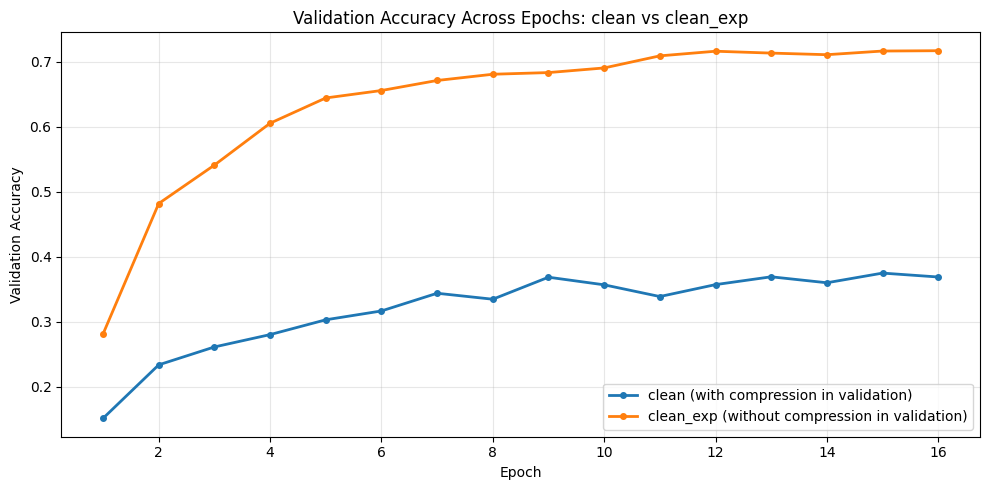

In [7]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# Compare only clean and clean_exp on validation accuracy across epochs.
candidate_proposal_roots = [
    Path("results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
    Path("../results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
]

proposal_root = None
for cand in candidate_proposal_roots:
    if cand.exists():
        proposal_root = cand
        break

if proposal_root is None:
    raise FileNotFoundError("Proposal root folder not found in candidate locations.")


def to_epoch_series(raw_vals):
    """Convert Val accuracies to a numeric epoch-wise series."""
    series = []
    for item in raw_vals:
        if isinstance(item, dict):
            vals = [float(v) for v in item.values()]
            series.append(sum(vals) / len(vals) if vals else float("nan"))
        else:
            series.append(float(item))
    return series


case_configs = [
    {
        "folder": "comm=clean",
        "label": "clean (with compression in validation)",
        "color": "tab:blue",
    },
    {
        "folder": "comm=clean_exp",
        "label": "clean_exp (without compression in validation)",
        "color": "tab:orange",
    },
]

series_by_case = {}
for cfg in case_configs:
    fp = proposal_root / cfg["folder"] / "final_training_results.json"
    if not fp.exists():
        raise FileNotFoundError(f"Missing file: {fp}")

    data = json.loads(fp.read_text(encoding="utf-8"))
    val_acc = data.get("Val accuracies")
    if not isinstance(val_acc, list) or len(val_acc) == 0:
        raise ValueError(f"Invalid or empty 'Val accuracies' in {fp}")

    series_by_case[cfg["label"]] = {
        "values": to_epoch_series(val_acc),
        "color": cfg["color"],
    }

max_epochs = max(len(v["values"]) for v in series_by_case.values())
epochs = list(range(1, max_epochs + 1))

plt.figure(figsize=(10, 5))
for label, payload in series_by_case.items():
    y = payload["values"]
    x = epochs[: len(y)]
    plt.plot(x, y, marker="o", linewidth=2.0, markersize=4, label=label, color=payload["color"])

plt.title("Validation Accuracy Across Epochs: clean vs clean_exp")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()